
# Figure 7: Curriculum Comparison — Attention weights, ablations and patching

06/05/2026

Interpretability plots for fine-tuned models trained under two curricula (`clean_early` (imbalanced), `static` (balanced)):
- **7A**: Attention weights to the condition token by layer
- **7B**: Condition-token ablations
- **7C**: Activation patching

Data loaded from `results/linear_interpolation_curriculum`.
Set `save_figures = True` to export SVGs to `figs/fig7/`.

In [1]:
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import json
import seaborn as sns
import pandas as pd
from importlib import reload
import os
import scipy.stats
from statannotations.Annotator import Annotator  # duplicate in cell 2 — keep one
from itertools import combinations
from matplotlib.ticker import FormatStrFormatter

import sys
sys.path.append('../../')

import src.datasets.DeonticEthicsDataset as deontic_utils
from src.models import Transformer
from src.plot_utils import format_axis, cPal, interpPal, dataPal, curricula_names
import src.plot_utils as plot_utils

import src.deontic_evals.evals as evals
import src.deontic_evals.deontic_patching as deontic_patching
import src.deontic_evals.attention_weights as deontic_attention
import src.deontic_evals.deontic_ablations as deontic_ablations


In [3]:
## set save path

fig7_path = 'figs/fig7'
os.makedirs(fig7_path, exist_ok=True)

save_figures = False

In [4]:
## device

device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(device)

mps


# Load data

In [5]:
## Load model and corpus
data_dir = "results/linear_interpolation_curriculum"

data_path_base = data_dir + "/clean_early/"
data_path_base += [fl for fl in os.listdir(data_path_base) if '.DS' not in fl][0]

data_runs = os.listdir(data_path_base)
data_runs = [dr for dr in data_runs if ('.DS' not in dr) and ('evals' not in dr)]

# Config
with open(os.path.join(data_path_base,data_runs[0], "model_config_train.json")) as f:
    config = json.load(f)

# Params
with open(os.path.join(data_path_base,data_runs[0], "params.json")) as f:
    params = json.load(f)

datafile = params['data_path']

with open(datafile , 'r') as file:
    data = json.load(file)

corpus = data['corpus']
RuleSystem = deontic_utils.RuleSet.from_dict(data['rules_plus_grammar'])
grammar = RuleSystem.grammar
train_data = data['train_data']
test_data = data['test_data']

stoi = grammar.stoi
itos = grammar.itos
vocab_size = grammar.vocab_size
eos_id = grammar.eos_id
features = grammar.variables
preambles = grammar.preambles
init_str = grammar.init_str

loss_switches  = [config['epochs'], 2*config['epochs']]

model = Transformer(
    vocab_size=params["vocab_size"],
    d_model=params["d_model"],
    n_heads=params["n_heads"],
    n_layers=params["n_layers"],
    dropout=params["dropout"],
    use_rotary_pe=True
)

model = model.to(device)

In [6]:
## collect_paths

datapath = data_dir
curricula =['clean_early', 'static']
curricula_order = ['clean_early', 'static']

curricula_paths = {}
for curr in curricula:
    cdir = os.listdir(os.path.join(data_dir, curr))
    cdir = [cc for cc in cdir if '.DS' not in cc]
    cpath = os.path.join(data_dir, curr, cdir[0])
    curricula_paths[curr] = os.path.join(data_dir, curr, cdir[0])

## Load checkpoints

In [ ]:
## extract phase checkpoints

phase_checkpoints = {}

for curr in curricula:

    cdir = os.listdir(os.path.join(datapath, curr))
    cdir = [cc for cc in cdir if '.DS' not in cc]
    cpath = os.path.join(datapath, curr, cdir[0])

    dataruns = os.listdir(cpath)
    dataruns = [dt for dt in dataruns if ('evals' not in dt) and ('.DS' not in dt)]
    
    with open(os.path.join(cpath, dataruns[0], "model_config_train.json")) as f:
        config = json.load(f)
   
    phase_checkpoints[curr] = {}
    for run in tqdm(dataruns):
        phase_checkpoints[curr][run] = {}
        checkpoints = torch.load(os.path.join(cpath, run, "history.pt"),  map_location=device)['checkpoints']
        phase_checkpoints[curr][run]['finetuned'] = checkpoints[params['n_epochs'] + params['n_epochs_fine_tune']]
    

100%|██████████| 2/2 [00:00<00:00,  3.08it/s]


## Fig7A: Condition-token attention weights

In [13]:
layers = list(range(params['n_layers']))
dfs = []

for curr in curricula:
    print(f'attention for curriculum: {curr}')
    for run in tqdm(phase_checkpoints[curr]):

        checkpoints = phase_checkpoints[curr][run]
        for layer in layers:

            attn_df = deontic_attention.rule_avg_attn_across_checkpoints(
                model, checkpoints, test_data, RuleSystem, device = device, layer=layer
            )
            attn_df['curriculum'] = curr
            attn_df['run'] = run
            attn_df['layer'] = layer
            dfs.append(attn_df)

dfs = pd.concat(dfs)

dfs['curriculum'] = pd.Categorical(dfs['curriculum'], 
                                     categories=curricula, 
                                     ordered=True)

attention for curriculum: clean_early


100%|██████████| 2/2 [00:07<00:00,  3.66s/it]


attention for curriculum: static


100%|██████████| 2/2 [00:06<00:00,  3.31s/it]


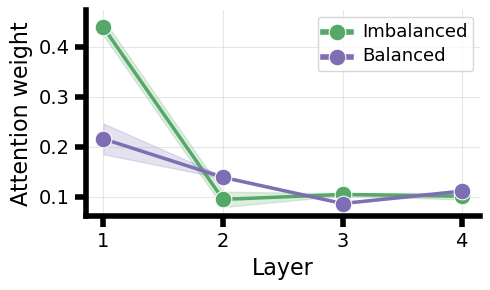

In [14]:
fig, ax = plt.subplots(figsize = (5, 3), sharex = True, sharey=True)

sns.lineplot(dfs, x = 'layer', y = 'mean_attn', hue = 'curriculum', ax=ax, marker = 'o', 
                palette = cPal,
                linewidth=4, markersize = 12)

ax.set_xticks(np.arange(len(layers)), labels = list(range(1, len(layers)+1)))
ax.set_xlabel('Layer')
ax.set_ylabel('Attention weight')
ax.set_yticks([0.1, 0.2,0.3,0.4])

ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

handles, labels = ax.get_legend_handles_labels()
ax.legend(title='', handles=handles[:2], labels=list(curricula_names.values()))

format_axis(ax)
ax.grid(alpha=0.3)

sns.despine()
fig.tight_layout()

if save_figures:
    fig.savefig(os.path.join(fig7_path,'attention_weights.svg'), transparent=True)

## Fig7B: Condition-token ablations

In [ ]:

token_ablations = []

for curr in curricula:
    print(f'attention for curriculum: {curr}')
    for run in tqdm(phase_checkpoints[curr]):
        checkpoint = phase_checkpoints[curr][run]['finetuned']
        for layer in layers:
            
            model.load_state_dict(checkpoint)
            model.eval()
            
            ablation_result = deontic_ablations.collect_token_ablation_scores(model, test_data, RuleSystem, layer)
            
            ablation_result['layer'] = layer
            ablation_result['curriculum'] = curr
            ablation_result['run'] = run
            token_ablations.append(ablation_result)

token_ablations = pd.concat(token_ablations)

token_ablations['curriculum'] = pd.Categorical(token_ablations['curriculum'], 
                                     categories = curricula_order, 
                                     ordered=True)

token_ablations = token_ablations.groupby(['curriculum', 'layer', 'ablation', 'run'],observed=True)['p_misaligned'].mean().reset_index()



attention for curriculum: clean_early


100%|██████████| 2/2 [00:04<00:00,  2.34s/it]


attention for curriculum: static


100%|██████████| 2/2 [00:04<00:00,  2.19s/it]


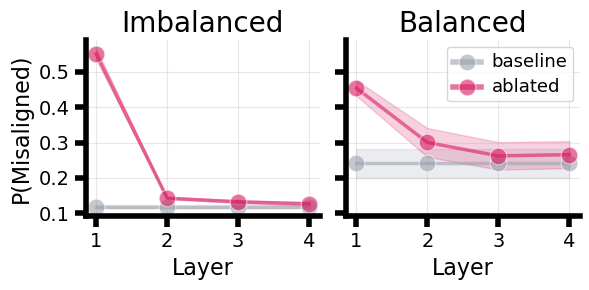

In [17]:
orientation ='h'

if orientation == 'v':
    nrows = len(curricula)
    ncols = 1
elif orientation == 'h':
    nrows = 1
    ncols = len(curricula)
fig, axs = plt.subplots(nrows, ncols,figsize = (3*ncols, 3*nrows), sharex = True, sharey=True)

for ci, curr in enumerate(curricula):
    ax=axs[ci]
    sdf = token_ablations[(token_ablations.curriculum == curr)].copy()
    sns.lineplot(sdf, x = 'layer', y = 'p_misaligned', hue = 'ablation', palette=interpPal,
                 marker = 'o', markersize = 12,
                 hue_order=['baseline', 'ablated'], ax=ax, alpha=0.6)
 
    ax.set_ylabel(f'P(Misaligned)')
    ax.set_xticks(list(range(4)), labels = list(range(1, 5)))
    if ci != len(curricula)-1:
        ax.legend().remove()
    else:
        ax.legend(title='')
    
    ax.set_xlabel('Layer')
    ax.set_title(curricula_names[curr])

    format_axis(ax)
    ax.set_title(curricula_names[curr], fontsize=20, y = 1)
    ax.grid(alpha=0.3)

axs[0].set_ylabel('P(Misaligned)')
sns.despine()
fig.tight_layout()

if save_figures:
    fig.savefig(os.path.join(fig7_path,'attention_ablations.svg'), transparent=True)

## Fig7C: Activation Patching

In [ ]:
patching = []

for curr in curricula:
    for run in tqdm(phase_checkpoints[curr]):
        checkpoint = phase_checkpoints[curr][run]['finetuned']
        
        model.load_state_dict(checkpoint)
        model.eval()
        df = deontic_patching.steer_probe_set(model, test_data, RuleSystem, patch_type = 'attention')
        df['curriculum'] = curr
        df['run'] = run
        patching.append(df)

patching = pd.concat(patching)

patching['curriculum'] = pd.Categorical(patching['curriculum'], 
                                     categories = curricula_order, 
                                     ordered=True)

patching = patching.groupby(['curriculum', 'layer', 'phase', 'run'],observed=True)[['p_misaligned','p_aligned']].mean().reset_index()
patching['p_ungrammatical'] = 1 - patching['p_misaligned'] - patching['p_aligned']
patching['phase'] = patching['phase'].replace({'base':'baseline'})

100%|██████████| 2/2 [00:06<00:00,  3.12s/it]


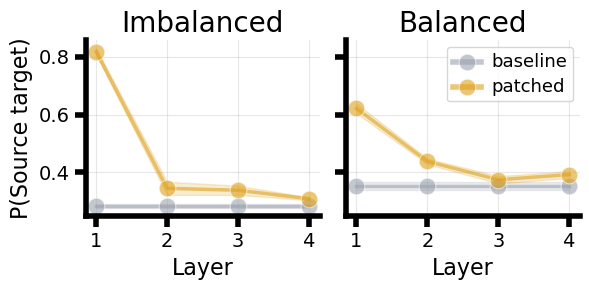

In [19]:
fig, axs = plt.subplots(1, len(curricula),figsize = (3*len(curricula), 3), sharex = True, sharey=True)

for ci, curr in enumerate(curricula):
    ax=axs[ci]
    sdf = patching[(patching.curriculum == curr)].copy()
    sns.lineplot(sdf, x = 'layer', y = 'p_aligned', hue = 'phase', palette=interpPal,
                 marker = 'o', markersize = 12,
                 hue_order=['baseline', 'patched'], ax=ax, alpha=0.6)
 
    ax.set_ylabel(f'Layer {layer}: P(Misaligned)')
    ax.set_xticks(list(range(4)), labels = list(range(1,5)))
    if ci != len(curricula)-1:
        ax.legend().remove()
    else:
        ax.legend(title='')
    ax.set_xlabel('Layer')
    ax.set_title(curricula_names[curr])

    format_axis(ax)
    ax.grid(alpha=0.3)
    ax.set_title(curricula_names[curr], fontsize=20, y = 1)

axs[0].set_ylabel('P(Source target)')
sns.despine()
fig.tight_layout()

if save_figures:
    fig.savefig(os.path.join(fig7_path,'activation_patching.svg'), transparent=True)